In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from specula.mmlib.analyse_data import plot_output_data
from specula.mmlib.plot_gain_opt import plot_gain_optimization

from specula.mmlib.compute_iffs import compute_and_save_influence_functions, compute_and_save_dcao_matrix
from check_calibration import check_calibration

Cupy import successfull. Installed version is: 14.0.1
Default device is GPU number  0
Cupy import successfull. Installed version is: 14.0.1
Default device is GPU number  0
Cupy import successfull. Installed version is: 14.0.1
Default device is CPU


In [2]:
# root_dir = '/raid1/mmenessini/results/Cascading'
# calib_dir = '/raid1/mmenessini/calibration/XAO'
# plot_output_data(root_dir=root_dir,calib_dir=calib_dir)

In [3]:
# root_dir = '/raid1/mmenessini/calibration/XAO'
# check_calibration(root_dir)

In [4]:
# root_dir = '/raid1/mmenessini/calibration/XAO'
# Npix = 160

# compute_and_save_dcao_matrix(root_dir, first_stage_tag='bmc2k_vlt', second_stage_tag='dm468_vlt', N1_modes=1300, N2_modes=300)
# compute_and_save_dcao_matrix(root_dir, first_stage_tag='bmc2k_vlt', second_stage_tag='bmc2k_vlt', N1_modes=1300, N2_modes=300)

# compute_and_save_influence_functions(root_dir,tag='dm241_vlt', pupil_pixels=Npix, n_acts=17,
#                                         geom='alpao', r0=10e-2, obsratio=0.0, pupil_mask_tag='vlt_pupil')

# compute_and_save_influence_functions(root_dir,tag='dm468_vlt', pupil_pixels=Npix, n_acts=24,
#                                         geom='alpao', r0=10e-2, obsratio=0.0, pupil_mask_tag='vlt_pupil')

In [5]:
# gain_dir = '/raid1/mmenessini/results/Cascading'
# plot_gain_optimization(root_dir=gain_dir)

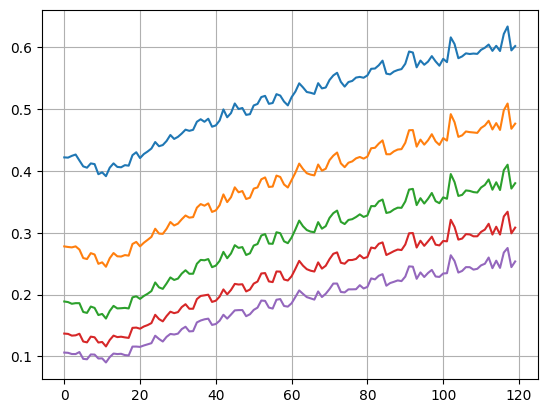

In [9]:
ogs06 = fits.getdata('/raid1/mmenessini/calibration/SOUL/optgains/pyr2.0_20x20_s0.6_138Nm_og.fits')
ogs08 = fits.getdata('/raid1/mmenessini/calibration/SOUL/optgains/pyr2.0_20x20_s0.8_186Nm_og.fits')
ogs10 = fits.getdata('/raid1/mmenessini/calibration/SOUL/optgains/pyr2.0_20x20_s1.0_238Nm_og.fits')
ogs12 = fits.getdata('/raid1/mmenessini/calibration/SOUL/optgains/pyr2.0_20x20_s1.2_291Nm_og.fits')
ogs14 = fits.getdata('/raid1/mmenessini/calibration/SOUL/optgains/pyr2.0_20x20_s1.4_349Nm_og.fits')

plt.figure()
plt.plot(ogs06)
plt.plot(ogs08)
plt.plot(ogs10)
plt.plot(ogs12)
plt.plot(ogs14)
plt.grid()

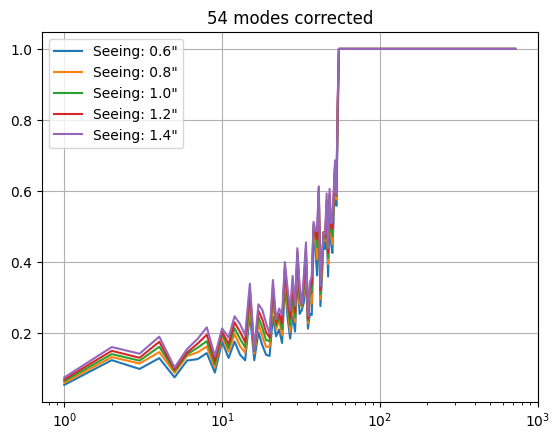

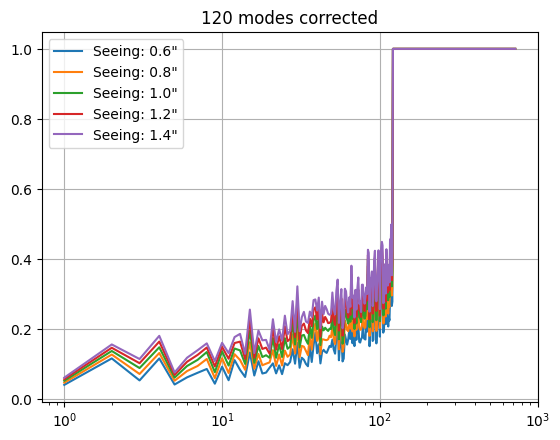

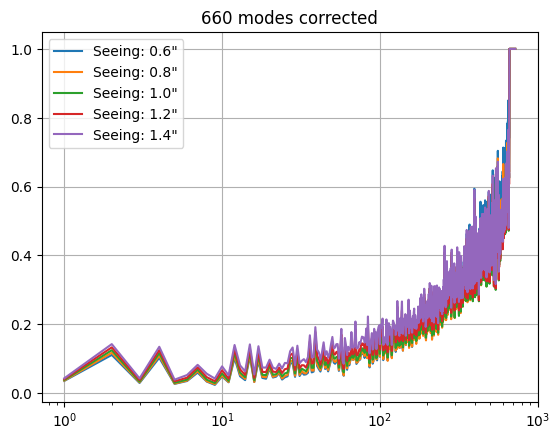

In [15]:
seeings = np.array([0.6,0.8,1.0,1.2,1.4])
modes = np.array([54,120,660])

cv = np.zeros([len(seeings),len(modes),720])

for i,seeing in enumerate(seeings):
    for j,N in enumerate(modes):
        cv[i,j,:] = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/data/s{seeing:1.1f}_{N:1.0f}modes_corrvec.fits')

x = np.arange(720)+1

for j,N in enumerate(modes):
    plt.figure()
    for i,seeing in enumerate(seeings):
        plt.plot(x,1-cv[i,j,:],label=f'Seeing: {seeing:1.1f}"')
    plt.xscale('log')
    plt.legend()
    plt.title(f'{N:1.0f} modes corrected')
    plt.grid()